# 03 - Wave Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_{tt} = c^2 u_{xx}$, $c = 1.0$

**IC:** $u(x,0) = \sin(\pi x)$, $u_t(x,0) = 0$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

**Note:** Wave equation is second-order in time - requires velocity IC.
Oscillatory nature makes it sensitive to sparse data.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    WaveFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'wave'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'c': 1.0}
RESULTS    = '../results/wave/'
FIGURES    = '../figures/wave/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, c=1.0)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

WaveFDM solved in 0.0158s


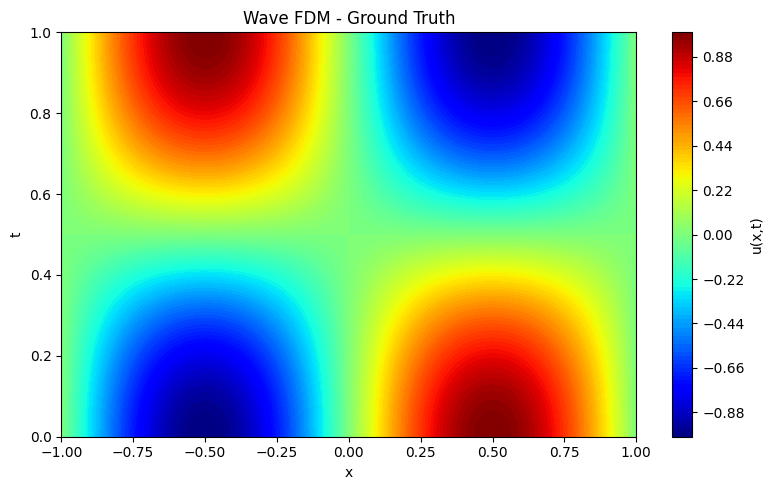

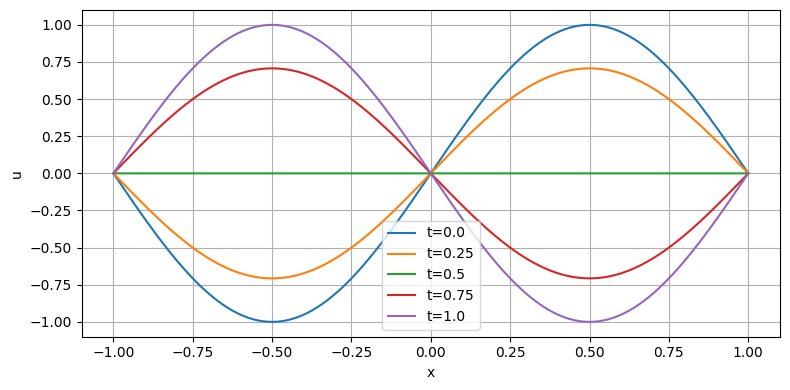

In [2]:
fdm = WaveFDM(nx=256, nt=2000, c=1.0)
fdm.solve()
fdm.plot_solution(title='Wave FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')
print(f'Wave data includes u_ic_dt: {"u_ic_dt" in data_clean_dense}')

Data ready
Wave data includes u_ic_dt: True


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Wave | Vanilla Clean | Epoch     0/10000] Total: 0.599779 | IC: 0.322352 | BC: 0.183737 | PDE: 0.018738


[Wave | Vanilla Clean | Epoch  1000/10000] Total: 0.029188 | IC: 0.010795 | BC: 0.017725 | PDE: 0.000134


[Wave | Vanilla Clean | Epoch  2000/10000] Total: 0.034521 | IC: 0.001490 | BC: 0.004029 | PDE: 0.005800


[Wave | Vanilla Clean | Epoch  3000/10000] Total: 0.002300 | IC: 0.000553 | BC: 0.000234 | PDE: 0.000303


...

[Wave | Vanilla Clean | Epoch  6000/10000] Total: 0.000608 | IC: 0.000252 | BC: 0.000158 | PDE: 0.000040


[Wave | Vanilla Clean | Epoch  7000/10000] Total: 0.000292 | IC: 0.000160 | BC: 0.000054 | PDE: 0.000016


[Wave | Vanilla Clean | Epoch  8000/10000] Total: 0.001216 | IC: 0.000261 | BC: 0.000244 | PDE: 0.000142


[Wave | Vanilla Clean | Epoch  9000/10000] Total: 0.000253 | IC: 0.000132 | BC: 0.000049 | PDE: 0.000014



Training complete in 206.88s


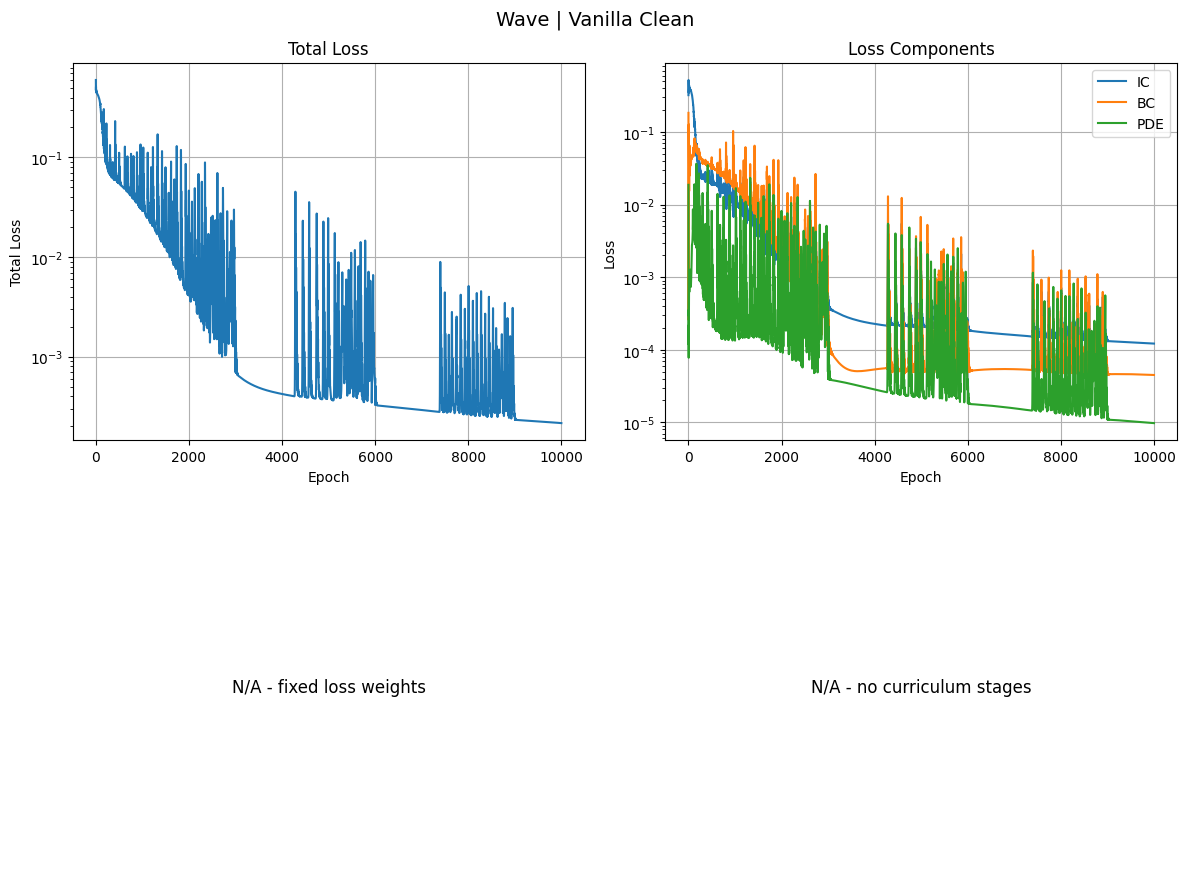

Saved: ../figures/wave/vanilla_clean_training.png
Saved: ../figures/wave/vanilla_clean_training.csv


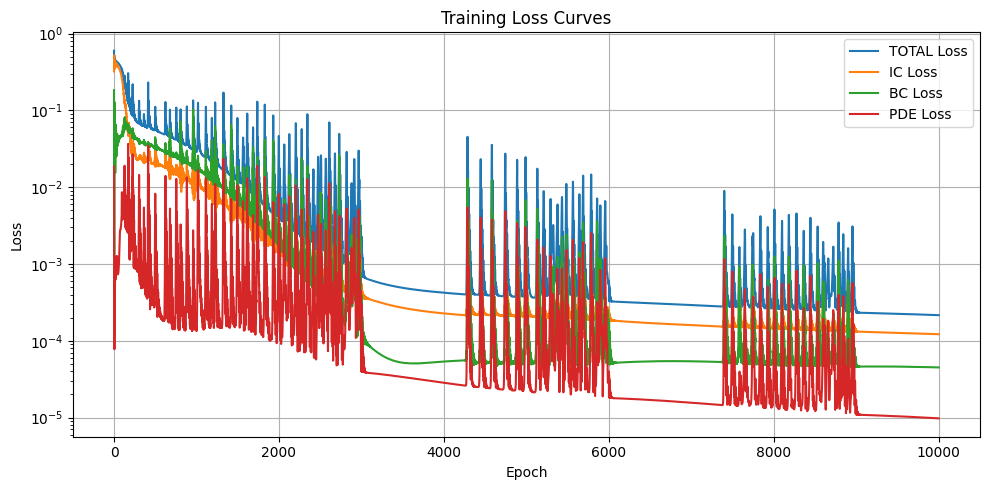

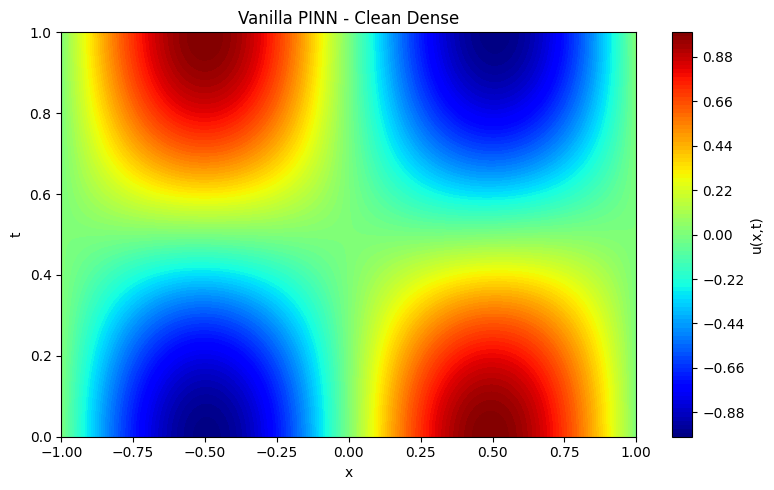

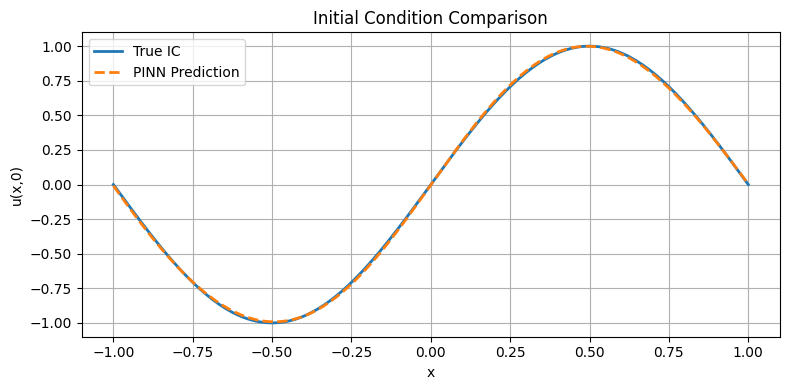

Saved: ../results/wave/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Wave | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Wave | Vanilla Noisy | Epoch     0/10000] Total: 0.450057 | IC: 0.422980 | BC: 0.019388 | PDE: 0.001538


[Wave | Vanilla Noisy | Epoch  1000/10000] Total: 0.053942 | IC: 0.032019 | BC: 0.021076 | PDE: 0.000169


[Wave | Vanilla Noisy | Epoch  2000/10000] Total: 0.099850 | IC: 0.027722 | BC: 0.026657 | PDE: 0.009094


[Wave | Vanilla Noisy | Epoch  3000/10000] Total: 0.032015 | IC: 0.015316 | BC: 0.010969 | PDE: 0.001146


[Wave | Vanilla Noisy | Epoch  4000/10000] Total: 0.023824 | IC: 0.013249 | BC: 0.010065 | PDE: 0.000102


...

[Wave | Vanilla Noisy | Epoch  6000/10000] Total: 0.022788 | IC: 0.012350 | BC: 0.010171 | PDE: 0.000054


[Wave | Vanilla Noisy | Epoch  7000/10000] Total: 0.022546 | IC: 0.012251 | BC: 0.010107 | PDE: 0.000038


[Wave | Vanilla Noisy | Epoch  8000/10000] Total: 0.022450 | IC: 0.012191 | BC: 0.010049 | PDE: 0.000042


[Wave | Vanilla Noisy | Epoch  9000/10000] Total: 0.022573 | IC: 0.012025 | BC: 0.010369 | PDE: 0.000036



Training complete in 186.96s


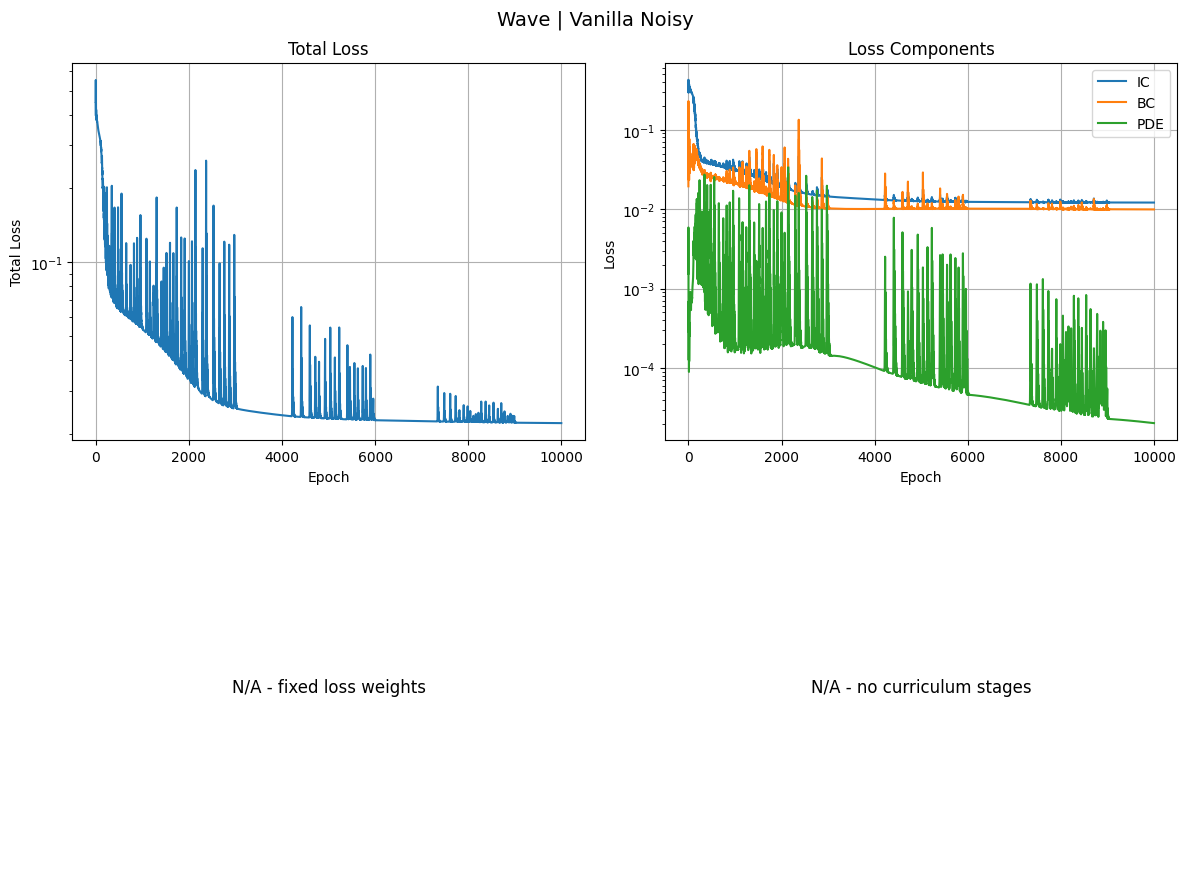

Saved: ../figures/wave/vanilla_noisy_training.png
Saved: ../figures/wave/vanilla_noisy_training.csv


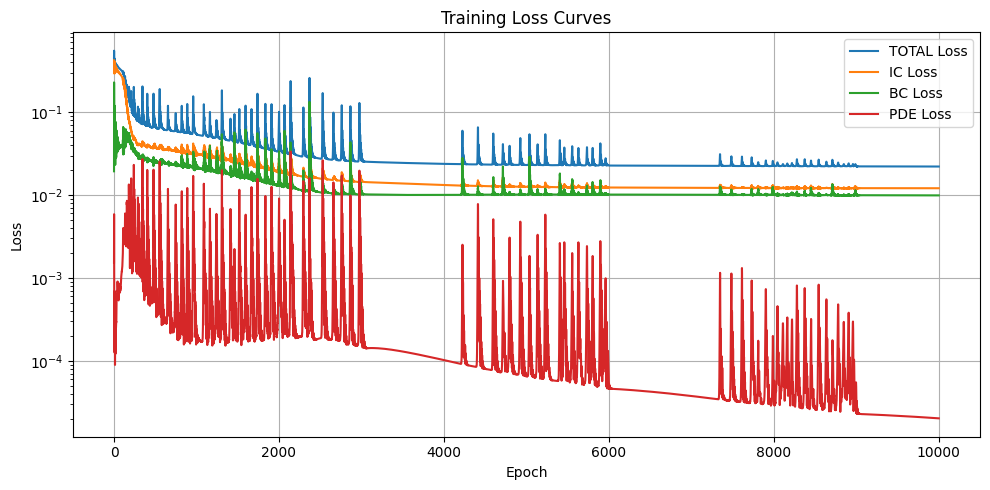

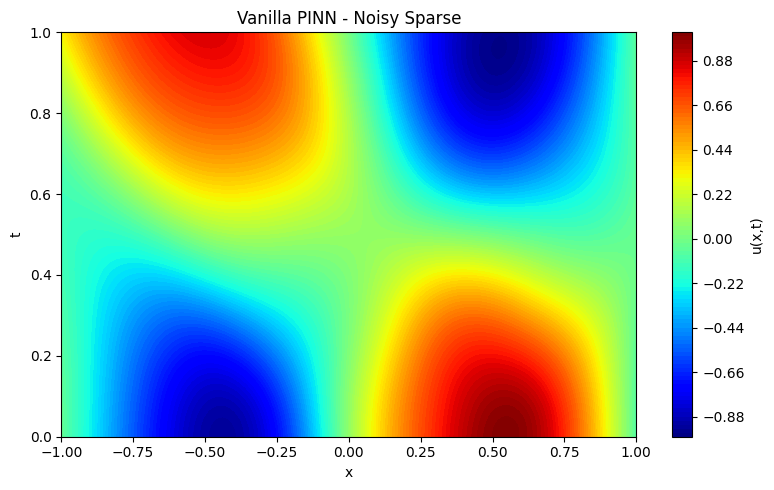

Saved: ../results/wave/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Wave | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Wave | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.622560 | IC: 0.574726 | BC: 0.041843 | PDE: 0.001198 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.095887 | IC: 0.018894 | BC: 0.023321 | PDE: 0.000783 | lam=(2.07,2.10,10.00)


[Wave | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.060143 | IC: 0.010449 | BC: 0.013694 | PDE: 0.000717 | lam=(1.98,2.36,10.00)


[Wave | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.022247 | IC: 0.005205 | BC: 0.005173 | PDE: 0.000126 | lam=(1.99,2.05,10.00)


[Wave | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.009476 | IC: 0.001580 | BC: 0.000830 | PDE: 0.000190 | lam=(1.42,7.27,6.32)


...

[Wave | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.002523 | IC: 0.000374 | BC: 0.001145 | PDE: 0.000366 | lam=(0.60,1.82,0.58)


[Wave | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.001195 | IC: 0.000463 | BC: 0.000021 | PDE: 0.000332 | lam=(1.70,0.10,1.22)


[Wave | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.010984 | IC: 0.000539 | BC: 0.004647 | PDE: 0.001157 | lam=(0.26,2.20,0.55)


[Wave | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.000930 | IC: 0.000298 | BC: 0.000040 | PDE: 0.000351 | lam=(1.30,0.17,1.53)



AC-PINN training complete in 220.72s


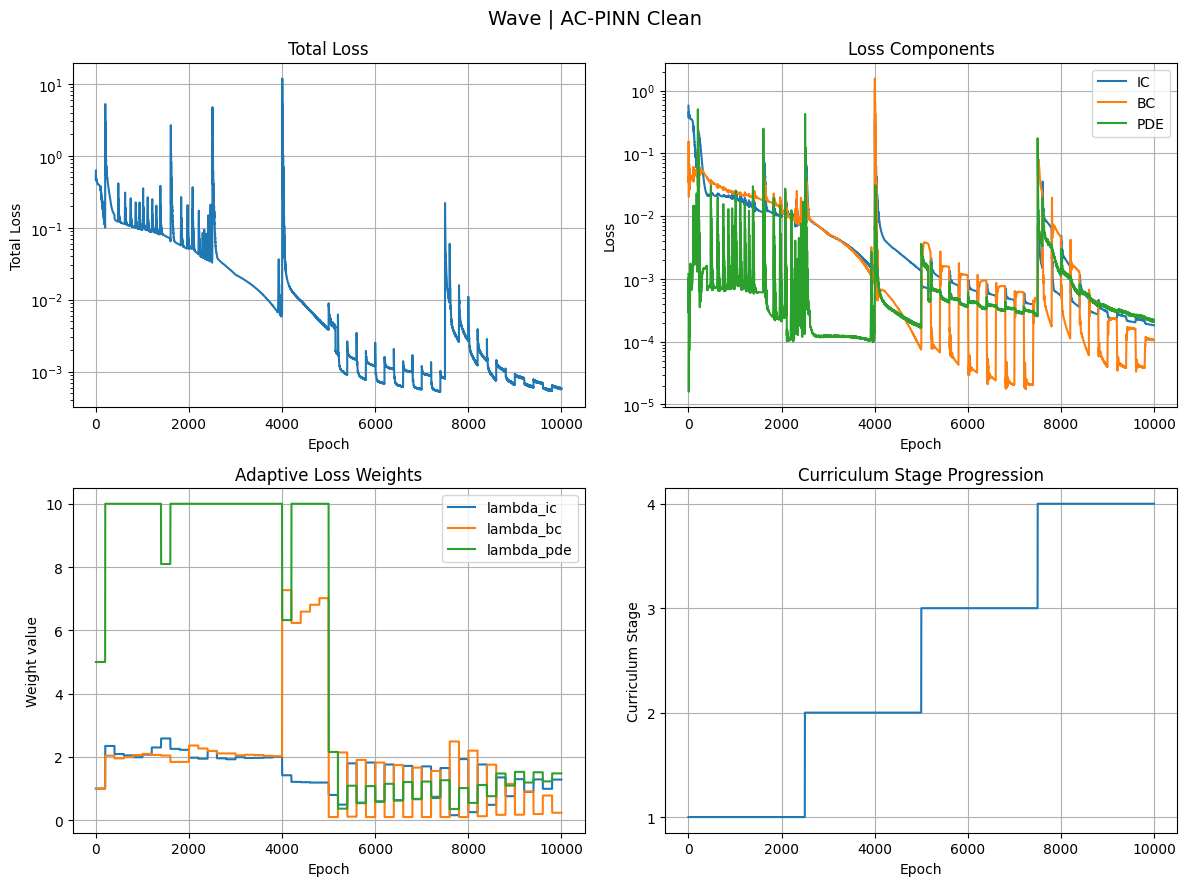

Saved: ../figures/wave/acpinn_clean_training.png
Saved: ../figures/wave/acpinn_clean_training.csv


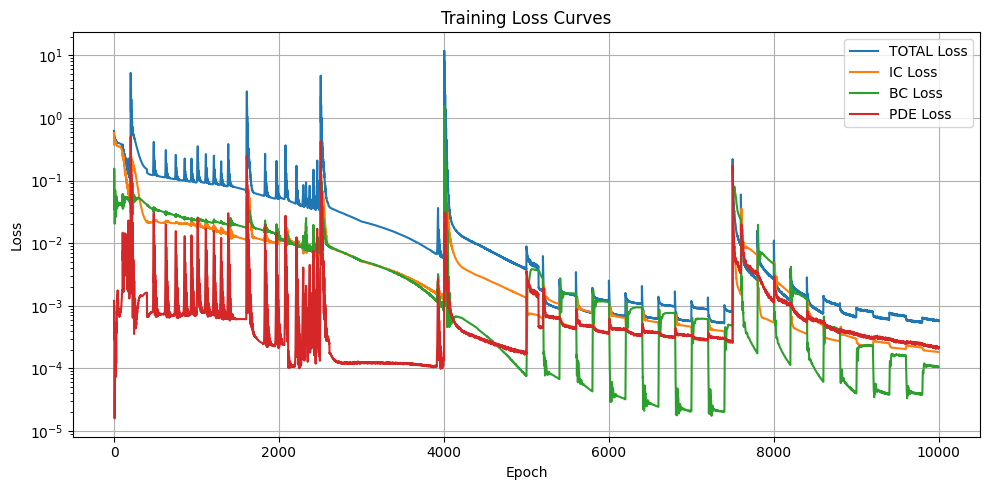

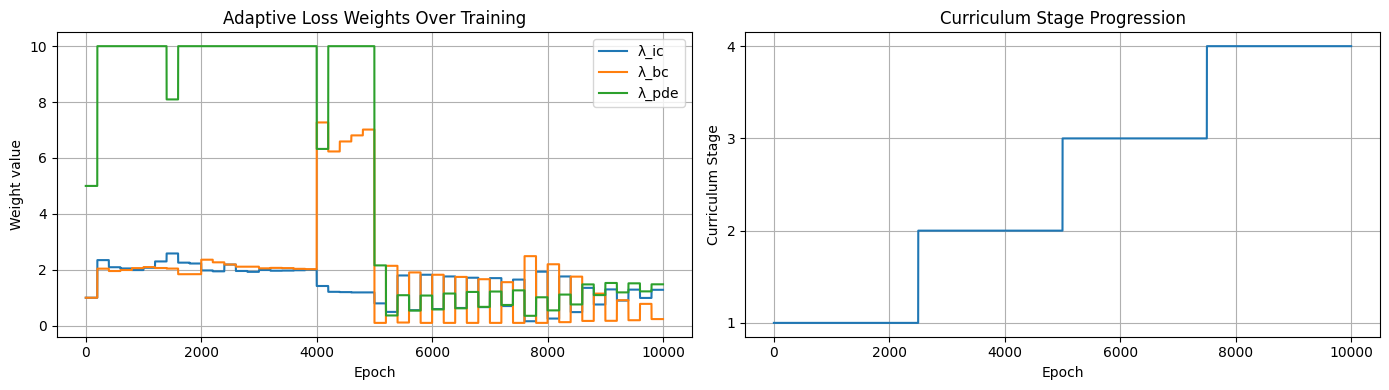

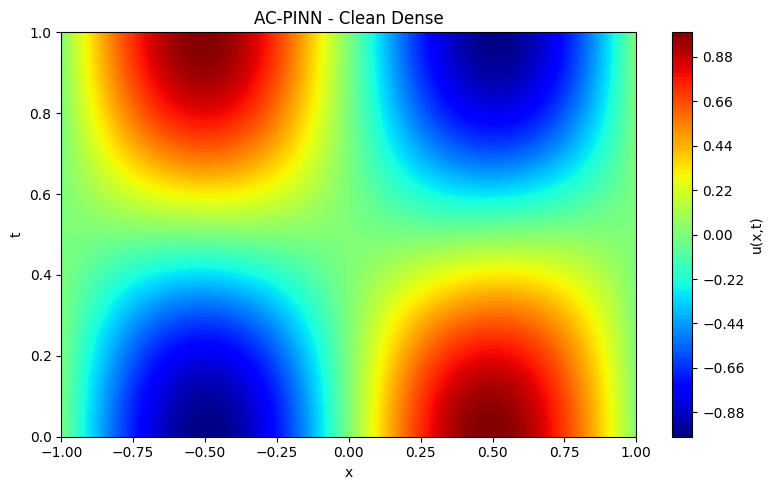

Saved: ../results/wave/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Wave | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Wave | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.750348 | IC: 0.607630 | BC: 0.138340 | PDE: 0.000876 | lam=(1.00,1.00,5.00)


[Wave | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.076632 | IC: 0.021681 | BC: 0.010305 | PDE: 0.000183 | lam=(1.45,4.22,10.00)


[Wave | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.093033 | IC: 0.020192 | BC: 0.009271 | PDE: 0.000185 | lam=(1.24,7.14,10.00)


[Wave | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.081907 | IC: 0.020299 | BC: 0.009554 | PDE: 0.000463 | lam=(2.12,3.90,3.69)


[Wave | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.094211 | IC: 0.017680 | BC: 0.010046 | PDE: 0.000456 | lam=(3.20,3.64,2.42)


...

[Wave | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.038155 | IC: 0.015596 | BC: 0.011107 | PDE: 0.002692 | lam=(1.59,1.13,0.27)


[Wave | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.036771 | IC: 0.014814 | BC: 0.011052 | PDE: 0.002524 | lam=(1.57,1.17,0.27)


[Wave | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.052925 | IC: 0.021041 | BC: 0.016253 | PDE: 0.014192 | lam=(1.23,0.95,0.83)


[Wave | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.034398 | IC: 0.013254 | BC: 0.011021 | PDE: 0.001983 | lam=(1.51,1.26,0.23)



AC-PINN training complete in 201.19s


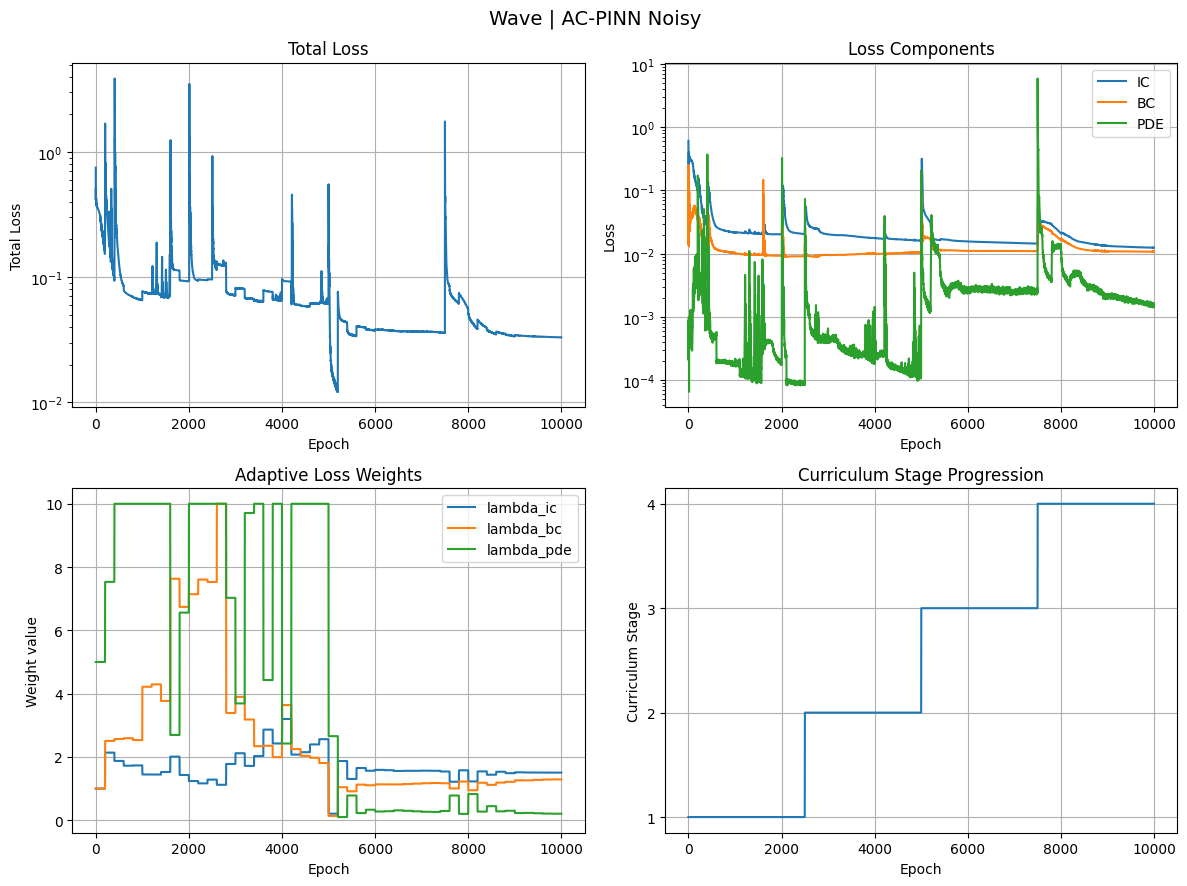

Saved: ../figures/wave/acpinn_noisy_training.png
Saved: ../figures/wave/acpinn_noisy_training.csv


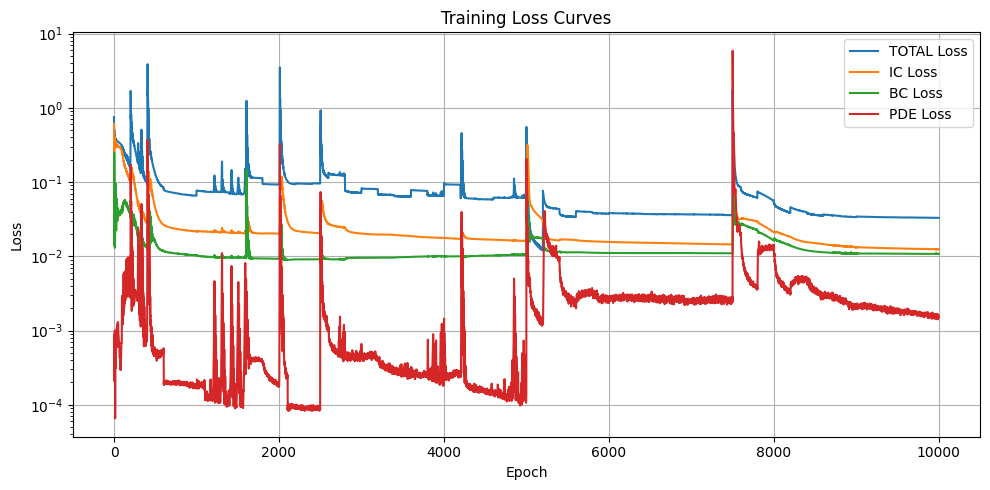

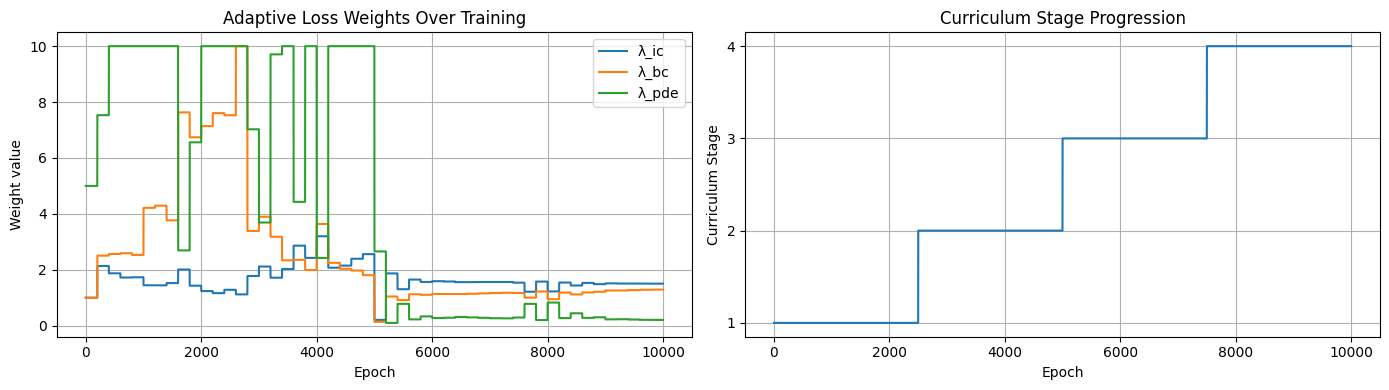

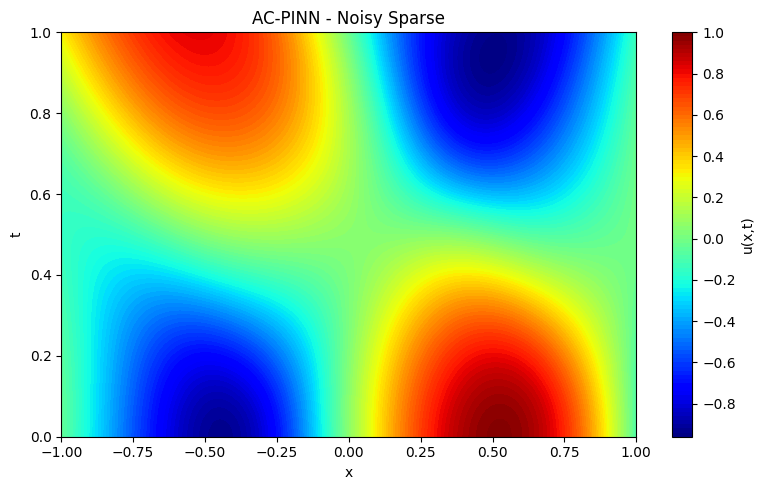

Saved: ../results/wave/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Wave | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Wave | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.020143   0.027047   0.007903   0.010046
  Vanilla (noisy)             0.156625   0.318737   0.063915   0.078112
  AC-PINN (clean)             0.020311   0.026377   0.008171   0.010130
  AC-PINN (noisy)             0.154429   0.314687   0.061300   0.077016


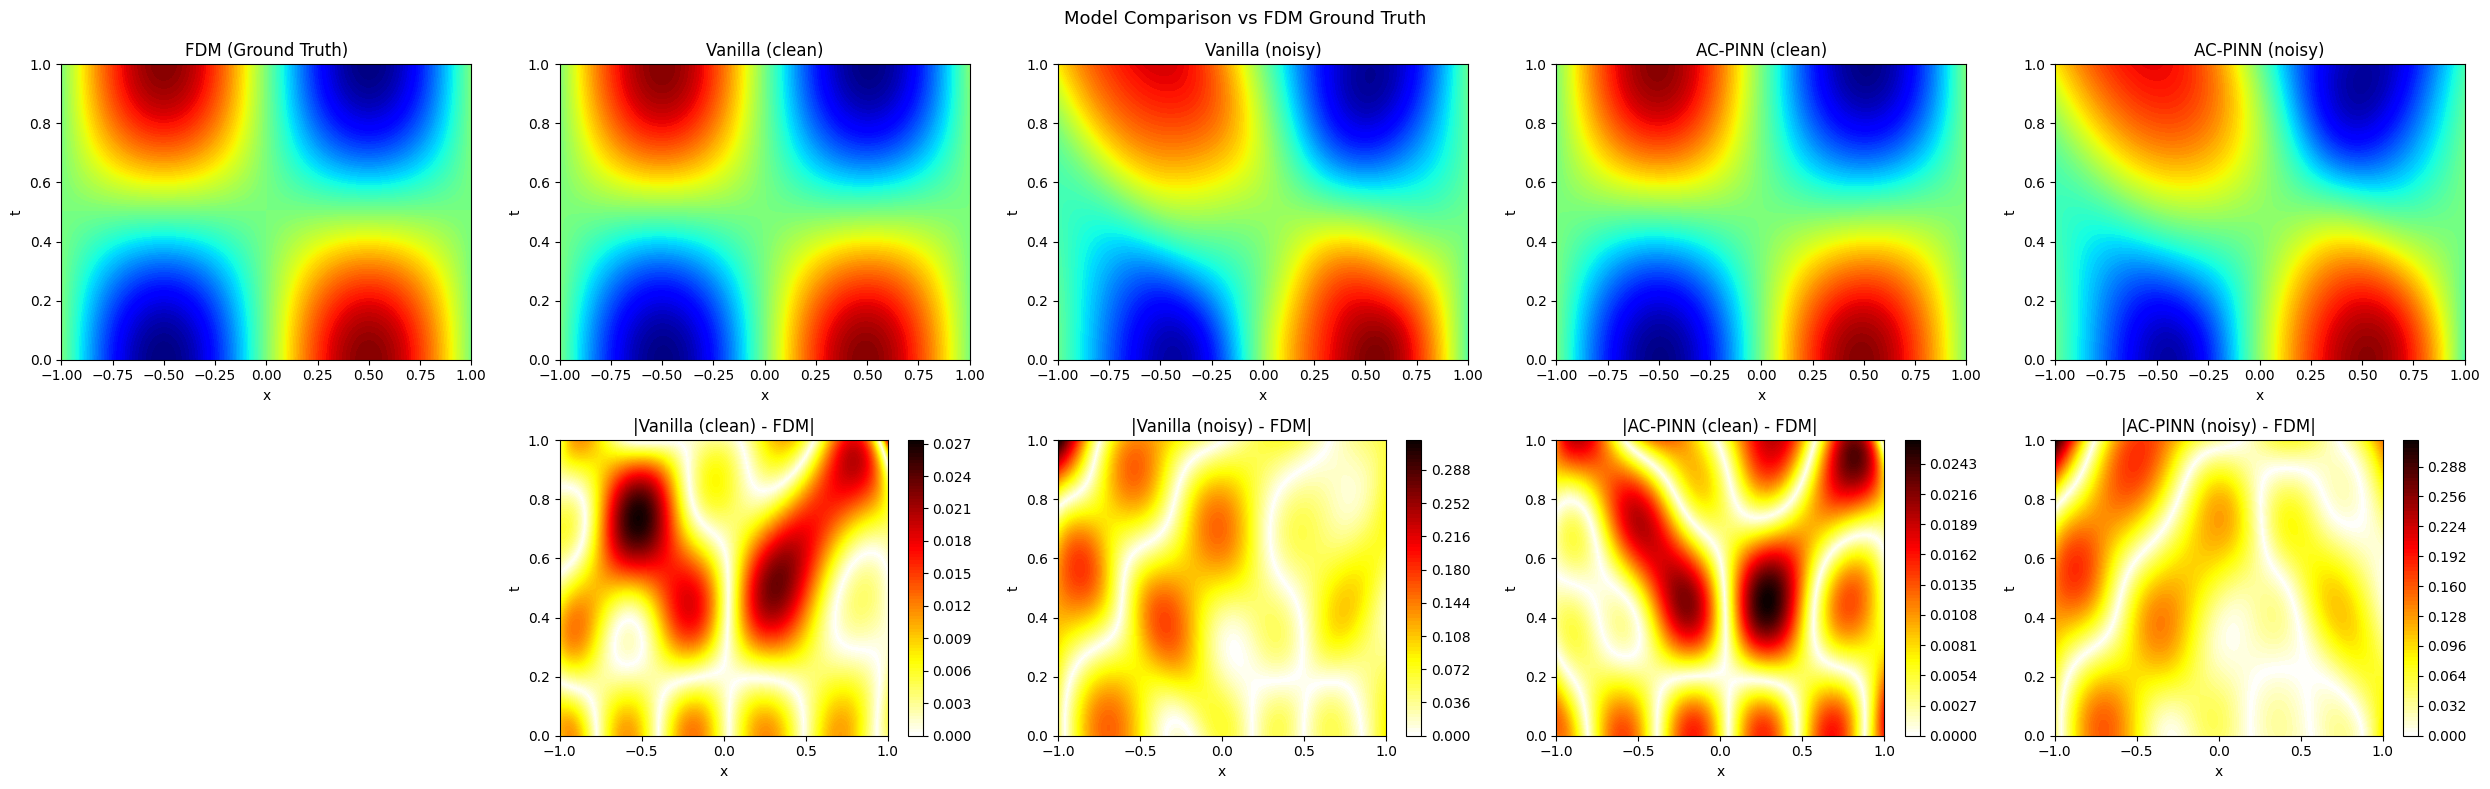

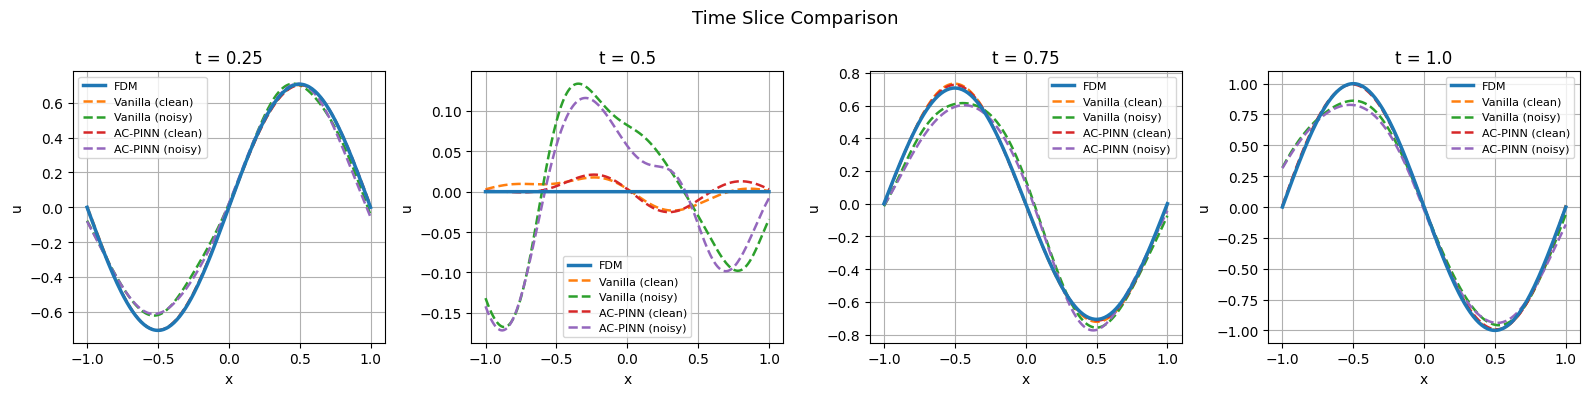

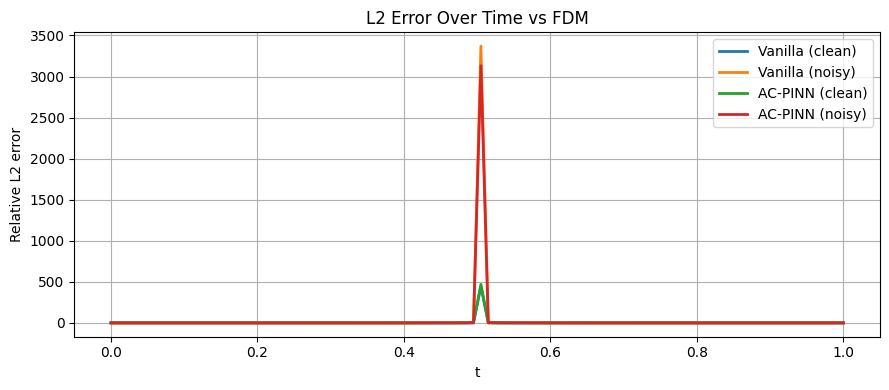

Saved: ../results/wave/benchmark_metrics.npy
Wave experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Wave experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.884290 | IC: 0.725853 | BC: 0.109244 | PDE: 0.009839


[Epoch  2500/5000] Total: 0.016292 | IC: 0.005854 | BC: 0.008603 | PDE: 0.000367



Training complete in 93.95s
[Epoch     0/5000] Stage 1/4 | Total: 0.893553 | IC: 0.739142 | BC: 0.150122 | PDE: 0.000858 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.078977 | IC: 0.014939 | BC: 0.012410 | PDE: 0.002252 | lam=(1.76,2.44,10.00)



AC-PINN training complete in 101.04s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.031754   0.058413   0.012675   0.015836
  AC-PINN ε=0.05              0.049599   0.085867   0.020104   0.024736

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.576750 | IC: 0.445126 | BC: 0.100662 | PDE: 0.006192


...


AC-PINN training complete in 101.16s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.046698   0.070551   0.018996   0.023289
  AC-PINN ε=0.1               0.118069   0.162007   0.045587   0.058883

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.704156 | IC: 0.600758 | BC: 0.090755 | PDE: 0.002529


[Epoch  2500/5000] Total: 0.174630 | IC: 0.080293 | BC: 0.084213 | PDE: 0.002025



Training complete in 94.11s
[Epoch     0/5000] Stage 1/4 | Total: 1.202044 | IC: 0.889487 | BC: 0.311438 | PDE: 0.000224 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 2.226960 | IC: 0.100587 | BC: 0.083424 | PDE: 0.175297 | lam=(1.36,4.05,10.00)



AC-PINN training complete in 101.01s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.062396   0.092509   0.024936   0.031118
  AC-PINN ε=0.2               0.210450   0.289969   0.084087   0.104955
Saved: ../results/wave/noise_study_metrics.npy
